# M03 — Curved boundaries: SVM kernels and tree ensembles

<!-- paper-first -->
### Begin with the paper question

**Read or revisit [PM04](../../curriculum/papers/modeling.md#pm04).** Use the assigned first-pass sections in the guide; if you already read them, return only to the relevant figure or claim. Do this before the technical explanation below.

**Motivation:** Is an apparent method advantage attributable to the model, its tuning, or unequal evaluation conditions?

Write a two-sentence prediction and one thing you cannot yet explain. Ask your AI tutor to locate evidence in the supplied paper and distinguish it from inference. A paper link motivates this question; it does not mean the paper uses every method demonstrated here.

**After the experiment:** revisit your prediction in the [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md). Explain one mechanism you now understand, cite a result from this notebook, and name a paper claim this exercise still cannot test. Keep a small demonstration distinct from a reproduction of the study.
<!-- /paper-first -->

**Original guided lab · 75–100 minutes.** Read 20 min, predict/code 35 min, failure investigation 20 min, explain and transfer 15 min. Run all cells in order in a fresh kernel. All executed data are synthetic unless explicitly stated. No network, GPU, or external dataset is required.

A straight decision boundary can fail even when the features contain enough information. To distinguish an inner ring from an outer ring in two dimensions, a linear score is poorly matched to the geometry. The exercise creates exactly this situation. It is a controlled demonstration of model capacity, not evidence that neuroimaging diagnosis generally has ring-shaped classes.

A support-vector classifier seeks a separating boundary with a margin while allowing violations controlled by C. An RBF kernel compares examples through a distance-based similarity. It can represent a curved boundary without explicitly listing every transformed feature. Gamma controls how locally similarity decays; a very large gamma can create isolated neighborhoods around training examples. Feature scaling changes distances, so a pipeline is essential. The kernel matrix must compare the correct training and evaluation samples; a square matrix of all participants is not automatically a valid precomputed-kernel experiment.

Trees split feature space into regions using threshold decisions. A random forest fits many randomized trees and aggregates their predictions. Averaging can reduce instability relative to one tree, but does not create additional independent participants. An ensemble can still memorize site effects or label leakage. More trees are not a substitute for more representative training data. Tree-based importance is also affected by correlations and feature characteristics, so it is not a direct map of causal anatomy.

The code compares a linear SVM, an RBF SVM, and a random forest on identical training and test indices. Hyperparameters are prespecified for this demonstration. Report the held-out score and training score together, then deliberately choose an extremely local RBF kernel. Near-perfect training accuracy with a poor held-out result illustrates overfitting. It is the gap under the chosen distribution that matters, not whether the algorithm sounds sophisticated.

There is a second audit to perform before using these methods with MRI. Ask whether rows correspond to independent participants, whether all fitted transformations stayed in training, and whether site or acquisition differences could dominate the geometry. A nonlinear method may amplify a nuisance pattern just as effectively as a biological one. Before expanding the search space, require a simple baseline and a valid split. If the model family was selected after inspecting the test results, those results have become validation evidence; a fresh evaluation is needed for an honest final claim.

## Transformation contract

Two-feature participant rows → scaled distances or threshold partitions → decision scores and labels. RBF similarity changes the representation; forest averaging combines fitted trees. Neither transformation adds samples or explains causation.

## Ask your AI tutor

```text
Explain this notebook one transformation at a time.
Before each cell ask me to predict shapes, units, and a check.
Give edits in executable cells of at most 20 lines.
Keep the prescribed split, random seed, and tests intact.
Distinguish generated suggestions from executed results.
After the failure experiment, ask me to explain the mechanism.
```

In [1]:
import numpy as np
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
X,y=make_circles(n_samples=500,factor=.35,noise=.09,random_state=403)
tr,te=train_test_split(np.arange(len(y)),test_size=.4,stratify=y,random_state=8)
models={'linear':SVC(kernel='linear'),'RBF':SVC(C=2,gamma=1),
        'forest':RandomForestClassifier(n_estimators=80,max_depth=5,random_state=8),
        'too_local':SVC(C=1e5,gamma=1e5)}
scores={}
for name,model in models.items():
    pipe=make_pipeline(StandardScaler(),model).fit(X[tr],y[tr])
    scores[name]=(pipe.score(X[tr],y[tr]),pipe.score(X[te],y[te]))
print('Train/test accuracy:',scores)
assert scores['RBF'][1]>.9 and scores['forest'][1]>.9
assert scores['too_local'][0]>.99 and scores['too_local'][1]<.7


Train/test accuracy: {'linear': (0.6366666666666667, 0.605), 'RBF': (1.0, 1.0), 'forest': (1.0, 0.985), 'too_local': (1.0, 0.51)}


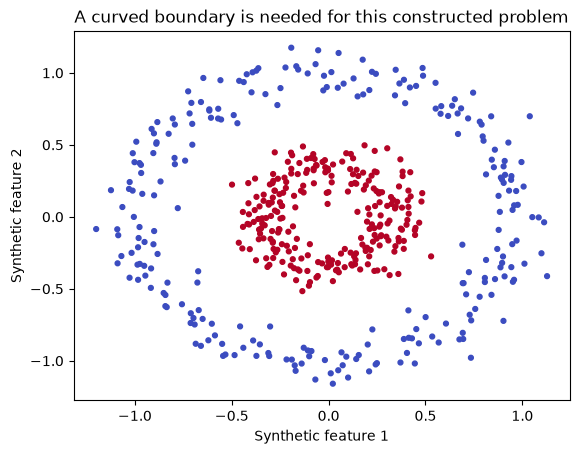

In [2]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0],X[:,1],c=y,s=12,cmap='coolwarm')
plt.xlabel('Synthetic feature 1');plt.ylabel('Synthetic feature 2')
plt.title('A curved boundary is needed for this constructed problem');plt.show()
assert scores['RBF'][1] > scores['linear'][1] + .2


## Deliberate failure and repair

The `too_local` model memorizes tiny regions around training points. Diagnose the training–test gap before attempting repair. A defensible repair would choose gamma and C inside inner folds, not increase them until the held-out score looks attractive. Keep the same participant splits across competing models.

## Your investigation

Ask AI to explain one SVM prediction using its similarity to training examples, and one forest prediction using splits. Do not request a biological narrative from these synthetic coordinates. Sketch a kernel matrix with training-by-training and test-by-training shapes. State why feature standardization affects an RBF model.

## Transfer to real neuroimaging

BrainIAK’s classification and FCMA tutorials show how actual fMRI patterns and connectivity features enter classifiers. Their data setup and preprocessing are separate requirements. A successful ring classifier here does not reproduce FCMA or validate a patient classifier.

**Primary teaching sources, pinned where hosted on GitHub:**

- [BrainIAK: classifiers](https://github.com/brainiak/brainiak-tutorials/blob/fb62ede943d9694fe703aee0df5f43ecf5558415/tutorials/03-classification.ipynb)
- [BrainIAK: precomputed connectivity kernels](https://github.com/brainiak/brainiak-tutorials/blob/fb62ede943d9694fe703aee0df5f43ecf5558415/tutorials/09-fcma.ipynb)
- [scikit-learn SVM guide](https://scikit-learn.org/stable/modules/svm.html)
- [scikit-learn ensemble guide](https://scikit-learn.org/stable/modules/ensemble.html)

Pinned upstream tutorials are a separate assignment; they have **not been executed** by this core lab. They may require data downloads, specialist dependencies, unfinished student cells, and additional compute.

## Exit questions and answer key

1. Does an ensemble create new independent evidence? **No, it recombines fits to existing data.**
2. What can a very large gamma do? **Make similarity too local, allowing memorization and weak transfer to unseen examples.**

### Return to the research question

Reopen [PM04](../../curriculum/papers/modeling.md#pm04) and your initial two-sentence prediction. In your [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md):

1. Cite one output or diagnostic from this lesson and explain the transformation it demonstrates.
2. Revise one claim or question from the paper, with a figure/section locator. State what this small exercise still cannot establish about the published result.
3. Ask AI to propose a next check. Accept, revise or reject it with a scientific reason. Then explain your decision aloud without reading the AI response.

Reuse this entry in the A2 portfolio when relevant; a separate report is unnecessary.
